# ML Program 1
---

## Dependencies for ML-1

In [7]:
import pandas as pd
import numpy as np

In [8]:
def covers(h,x):
    """Check if hypothesis h covers instance x"""
    return all(h[i] == '?' or h[i] == x[i] for i in range(len(h)))

def more_general_or_equals(h1,h2):
    """Check if h1 is more general than or equal to h2"""
    return all(h1[i] == h2[i] or h1[i] == '?' for i in range(len(h1)))

In [10]:
data=pd.read_csv("ML1-Dataset.csv")
print(data)
print("--------------------------------------------------------------------------------")
print(data.shape)

   Example    Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0        1  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1        2  Sunny    Warm     High  Strong  Warm     Same        Yes
2        3  Rainy    Cold     High  Strong  Warm   Change         No
3        4  Sunny    Warm     High  Strong  Cool   Change        Yes
--------------------------------------------------------------------------------
(4, 8)


In [11]:
X=data.iloc[:,1:-1]
print(X)

     Sky AirTemp Humidity    Wind Water Forecast
0  Sunny    Warm   Normal  Strong  Warm     Same
1  Sunny    Warm     High  Strong  Warm     Same
2  Rainy    Cold     High  Strong  Warm   Change
3  Sunny    Warm     High  Strong  Cool   Change


In [12]:
Y=data.iloc[:,-1]
print(Y)

0    Yes
1    Yes
2     No
3    Yes
Name: EnjoySport, dtype: object


In [13]:
# Initialize variables/hypothesis
nums_attributes=X.shape[1]
S=['0'] * nums_attributes
G=[['?'] * nums_attributes]

# Candidate Elimination algorithm
for i,x in X.iterrows():
    x = list(x)
    if Y[i] == "Yes": # Positive Example
        # Remove G hypothesis that do not cover x
        G = [g for g in G if covers(g,x)]

        # Generalize S Minimally
        for j in range(nums_attributes):
            if S[j] == '0':
                S[j] = x[j]
            elif S[j] != x[j]:
                S[j]= '?'

    else: # Negative Example
        G_new = []

        for g in G:
            if covers(g,x):
                for j in range(nums_attributes):
                    if g[j] == '?':
                        if S[j] != '?' and S[j] != x[j]:
                            g_copy = g.copy()
                            g_copy[j] = S[j]

                            # Valid specialization checks
                            if more_general_or_equals(g_copy, S) and not covers(g_copy, x):
                                G_new.append(g_copy)
            else:
                G_new.append(g)

        G = G_new

# Remove Duplicate
G = [list(g) for g in set(tuple(g) for g in G)]

In [14]:
print("Final Specific hypothesis (S):")
print(S,"\n")
print("---------------------------------------------------")
print("\nFinal General hypothesis (G):")
for g in G:
    print(g)

Final Specific hypothesis (S):
['Sunny', 'Warm', '?', 'Strong', '?', '?'] 

---------------------------------------------------

Final General hypothesis (G):
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']


# ML Program 2
---

## Dependencies for ML-2

In [15]:
import pandas as pd
import numpy as np
import math

In [16]:
def read_data(filename):
    data=pd.read_csv(filename)

    metadata=list(data.columns)
    traindata=data.values.tolist()

    return (metadata,traindata)

metadata,traindata=read_data("ML2-Dataset.csv")

print(f"{metadata=}")
print("----------------------------------------------------------------------")
for i in traindata:
    print(i)

metadata=['Outlook', 'Temperature', 'Humidity', 'Windy', 'PlayTennis']
----------------------------------------------------------------------
['Sunny', 'Hot', 'High', 'Weak', 'No']
['Sunny', 'Hot', 'High', 'Strong', 'No']
['Overcast', 'Hot', 'High', 'Weak', 'Yes']
['Rainy', 'Mild', 'High', 'Weak', 'Yes']
['Rainy', 'Cool', 'Normal', 'Weak', 'Yes']
['Rainy', 'Cool', 'Normal', 'Strong', 'No']
['Overcast', 'Cool', 'Normal', 'Strong', 'Yes']
['Sunny', 'Mild', 'High', 'Weak', 'No']
['Sunny', 'Cool', 'Normal', 'Weak', 'Yes']
['Rainy', 'Mild', 'Normal', 'Weak', 'Yes']
['Sunny', 'Mild', 'Normal', 'Strong', 'Yes']
['Overcast', 'Mild', 'High', 'Strong', 'Yes']
['Overcast', 'Hot', 'Normal', 'Weak', 'Yes']
['Rainy', 'Mild', 'High', 'Strong', 'No']


In [17]:
class Node:
    def __init__(self,attribute):
        self.attribute=attribute
        self.children=[]
        self.answer=""

    def __str__(self):
        return self.attribute


In [18]:
def subtables(data,col,delete):
    dic={}
    items=np.unique(data[:,col])
    count=np.zeros(items.shape[0],dtype=np.int32)

    for x in range(items.shape[0]):
        for y in range(data.shape[0]):
            if data[y, col]==items[x]:
                count[x]+=1

    for x in range(items.shape[0]):
        dic[items[x]]=np.empty((count[x],data.shape[1]),dtype="|S32")
        pos=0
        for y in range(data.shape[0]):
            if data[y,col]==items[x]:
                dic[items[x]][pos]=data[y]
                pos+=1

        if delete:
            dic[items[x]]=np.delete(dic[items[x]],col,1)

    return items, dic

In [19]:
def entropy(S):
    items=np.unique(S)

    if items.size==1:
        return 0

    counts=np.zeros(items.shape[0])
    sums=0

    for x in range(items.shape[0]):
        counts[x]=sum(S==items[x])/float(S.size)

    for count in counts:
        if count>0:
            sums+= -count * math.log(count,2)

    return sums

In [20]:
def gain_ratio(data,col):
    items, tables = subtables(data,col,delete=False)

    total_size=data.shape[0]

    total_entropy=entropy(data[:,-1])
    weighted_entropy=0
    intrinsic_value=0

    for value in items:
        subset=tables[value]
        ratio=subset.shape[0]/total_size

        weighted_entropy+=ratio*entropy(subset[:,-1])

        if ratio>0:
            intrinsic_value-=ratio*math.log(ratio,2)

    information_gain=total_entropy-weighted_entropy

    if intrinsic_value==0:
        return 0

    return information_gain/intrinsic_value

In [21]:
def create_node(data,metadata):
    if (np.unique(data[:,-1]).shape[0]==1):
        node = Node("")
        node.answer=np.unique(data[:,-1])[0]
        return node

    gains=np.zeros((data.shape[1]-1,1))

    for col in range(data.shape[1]-1):
        gains[col]=gain_ratio(data,col)

    split=np.argmax(gains)

    node=Node(metadata[split])
    metadata=np.delete(metadata,split,0)

    items, dic = subtables(data,split,delete=True)

    for value in items:
        child=create_node(dic[value],metadata)
        node.children.append((value,child))

    return node

In [22]:
def empty(size):
    s=""
    for x in range(size):
        s+=" "
    return s

In [23]:
def print_tree(node, level):
    if node.answer != "":
        print(empty(level), node.answer)
        return

    print(empty(level), node.attribute)

    for value, n in node.children:
        print(empty(level + 1), value)
        print_tree(n, level + 2)

In [24]:
metadata, traindata = read_data('ML2-Dataset.csv')
data = np.array(traindata)
# print(data)
data1 = np.array(metadata)
# print(data1)

node = create_node(data, metadata)
print_tree(node, 0)

 Outlook
  Overcast
   b'Yes'
  Rainy
   Windy
    b'Strong'
     b'No'
    b'Weak'
     b'Yes'
  Sunny
   Humidity
    b'High'
     b'No'
    b'Normal'
     b'Yes'


# ML Program 3
---

## Dependencies for ML-3

In [25]:
import numpy as np

In [26]:
X=np.array(
    [[5,2],[6,4],[7,5],[8,6],[4,3],[9,8],[6,7],[7,9],[5,6],[8,4]],
    dtype=float)
y=np.array([
    [50],[65],[75],[80],[55],[90],[85],[95],[70],[78]],
    dtype=float)
X=(X-np.mean(X,axis=0))/np.std(X,axis=0)

In [27]:
class NeuralNetwork:
    def __init__(self,input_size,hidden_size,output_size,lr=0.1):
        self.lr=lr

        self.W1=np.random.randn(input_size,hidden_size)
        self.b1=np.zeros((1,hidden_size))

        self.W2=np.random.randn(hidden_size,output_size)
        self.b2=np.zeros((1,output_size))

    def relu(self,x):
        return np.maximum(0,x)

    def relu_derivative(self,x):
        return (x>0).astype(float)

    def forward(self,X):

        self.z1=np.dot(X,self.W1)+self.b1
        self.a1=self.relu(self.z1)

        self.z2=np.dot(self.a1,self.W2)+self.b2
        self.ouput=self.z2

        return self.ouput
    def backward(self,X,y):
        m=X.shape[0]

        error=self.ouput-y

        dW2=np.dot(self.a1.T,error)/m
        db2=np.sum(error,axis=0,keepdims=True)/m

        hidden_error=np.dot(error,self.W2.T)

        hidden_delta=hidden_error * self.relu_derivative(self.z1)

        dW1=np.dot(X.T,hidden_delta)/m
        db1=np.sum(hidden_delta,axis=0,keepdims=True)/m

        self.W2-=self.lr*dW2
        self.b2-=self.lr*db2
        self.W1-=self.lr*dW1
        self.b1-=self.lr*db1

    def train(self,X,y,epochs):
        for i in range(epochs):
            self.forward(X)
            self.backward(X,y)

            if i%1000==0:
                loss=np.mean((y-self.ouput)**2)
                print(f"Epoch {i},Loss:{loss:.4f}")

In [28]:
nn=NeuralNetwork(input_size=2,hidden_size=5,output_size=1,lr=0.01)
nn.train(X,y,epochs=10000)

print("\nPredicted Scores:")
predictions=nn.forward(X)
print(predictions)

print("\nActual Scores:")
print(y)

Epoch 0,Loss:6032.5677
Epoch 1000,Loss:1.2154
Epoch 2000,Loss:0.8360
Epoch 3000,Loss:0.8271
Epoch 4000,Loss:0.8269
Epoch 5000,Loss:0.8269
Epoch 6000,Loss:0.8269
Epoch 7000,Loss:0.8269
Epoch 8000,Loss:0.8269
Epoch 9000,Loss:0.8269

Predicted Scores:
[[50.        ]
 [64.07563025]
 [77.22689076]
 [80.        ]
 [55.        ]
 [90.        ]
 [83.81512605]
 [95.        ]
 [70.66386555]
 [77.21848739]]

Actual Scores:
[[50.]
 [65.]
 [75.]
 [80.]
 [55.]
 [90.]
 [85.]
 [95.]
 [70.]
 [78.]]


# ML Program 4
---


## Dependencies for ML-4

In [29]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [30]:
iris = load_iris()

X = iris.data
Y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

In [31]:
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['species'] = iris.target_names[Y]

data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [32]:
"""
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled
"""

scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

array([[0.22222222, 0.625     , 0.06779661, 0.04166667],
       [0.16666667, 0.41666667, 0.06779661, 0.04166667],
       [0.11111111, 0.5       , 0.05084746, 0.04166667],
       [0.08333333, 0.45833333, 0.08474576, 0.04166667],
       [0.19444444, 0.66666667, 0.06779661, 0.04166667],
       [0.30555556, 0.79166667, 0.11864407, 0.125     ],
       [0.08333333, 0.58333333, 0.06779661, 0.08333333],
       [0.19444444, 0.58333333, 0.08474576, 0.04166667],
       [0.02777778, 0.375     , 0.06779661, 0.04166667],
       [0.16666667, 0.45833333, 0.08474576, 0.        ],
       [0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667],
       [0.38888889, 1.        , 0.08474576, 0.125     ],
       [0.30555556, 0.79166667, 0.05084746, 0.125     ],
       [0.22222222, 0.625     ,

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [34]:
clf = GaussianNB()
clf.fit(X_train, Y_train)
Y_pred=clf.predict(X_test)

d={0:"setosa",1:"versicolor",2:"virginica"}
Y_predict=[d[i] for i in list(Y_pred)]

Y_predict

['versicolor',
 'setosa',
 'virginica',
 'versicolor',
 'versicolor',
 'setosa',
 'versicolor',
 'virginica',
 'versicolor',
 'versicolor',
 'virginica',
 'setosa',
 'setosa',
 'setosa',
 'setosa',
 'versicolor',
 'virginica',
 'versicolor',
 'versicolor',
 'virginica',
 'setosa',
 'virginica',
 'setosa',
 'virginica',
 'virginica',
 'virginica',
 'virginica',
 'virginica',
 'setosa',
 'setosa']

In [35]:
cm=confusion_matrix(Y_test,Y_pred)
print("Confusion Matrix:\n",cm)
print("Accuracy:", accuracy_score(Y_test,Y_pred))
print("\nClassification Report:\n")
print(classification_report(Y_test,Y_pred))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# ML Program 5
---

## Dependencies for ML-5

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [4]:
dataset=load_iris()
x_train,x_test,y_train,y_test=train_test_split(dataset["data"],dataset["target"],random_state=0)

kn=KNeighborsClassifier(n_neighbors=3)
kn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [5]:
for i in range(len(x_test)):
    x=x_test[i]
    x_new=np.array([x])
    prediction=kn.predict(x_new)
    print(f"Target={y_test[i]} {dataset['target_names'][y_test[i]]} Predicted={prediction}{dataset['target_names'][prediction]}")
print(kn.score(x_test,y_test))

Target=2 virginica Predicted=[2]['virginica']
Target=1 versicolor Predicted=[1]['versicolor']
Target=0 setosa Predicted=[0]['setosa']
Target=2 virginica Predicted=[2]['virginica']
Target=0 setosa Predicted=[0]['setosa']
Target=2 virginica Predicted=[2]['virginica']
Target=0 setosa Predicted=[0]['setosa']
Target=1 versicolor Predicted=[1]['versicolor']
Target=1 versicolor Predicted=[1]['versicolor']
Target=1 versicolor Predicted=[1]['versicolor']
Target=2 virginica Predicted=[2]['virginica']
Target=1 versicolor Predicted=[1]['versicolor']
Target=1 versicolor Predicted=[1]['versicolor']
Target=1 versicolor Predicted=[1]['versicolor']
Target=1 versicolor Predicted=[1]['versicolor']
Target=0 setosa Predicted=[0]['setosa']
Target=1 versicolor Predicted=[1]['versicolor']
Target=1 versicolor Predicted=[1]['versicolor']
Target=0 setosa Predicted=[0]['setosa']
Target=0 setosa Predicted=[0]['setosa']
Target=2 virginica Predicted=[2]['virginica']
Target=1 versicolor Predicted=[1]['versicolor']
Ta

In [7]:
correct=0
wrong=0

for i in range(len(x_test)):
    x=x_test[i]
    x_new=np.array([x])
    prediction=kn.predict(x_new)

    actual=y_test[i]
    predicted=prediction[0]

    if actual==predicted:
        result="Correct"
        correct+=1
    else:
        result="Wrong"
        wrong+=1

    print("Target=",actual,dataset["target_names"][actual],
         "Predicted=",predicted,dataset["target_names"][predicted],
         " -> ",result)

print("\nTotal Correct:",correct)
print("Total Wrong:",wrong)
print("Accuracy:",kn.score(x_test,y_test))

Target= 2 virginica Predicted= 2 virginica  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 0 setosa Predicted= 0 setosa  ->  Correct
Target= 2 virginica Predicted= 2 virginica  ->  Correct
Target= 0 setosa Predicted= 0 setosa  ->  Correct
Target= 2 virginica Predicted= 2 virginica  ->  Correct
Target= 0 setosa Predicted= 0 setosa  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 2 virginica Predicted= 2 virginica  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 0 setosa Predicted= 0 setosa  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Correct
Target= 1 versicolor Predicted= 1 versicolor  ->  Corr

# ML Program 6
---

## Dependencies for ML-6

In [2]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

C:\Users\BMSIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\BMSIT\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


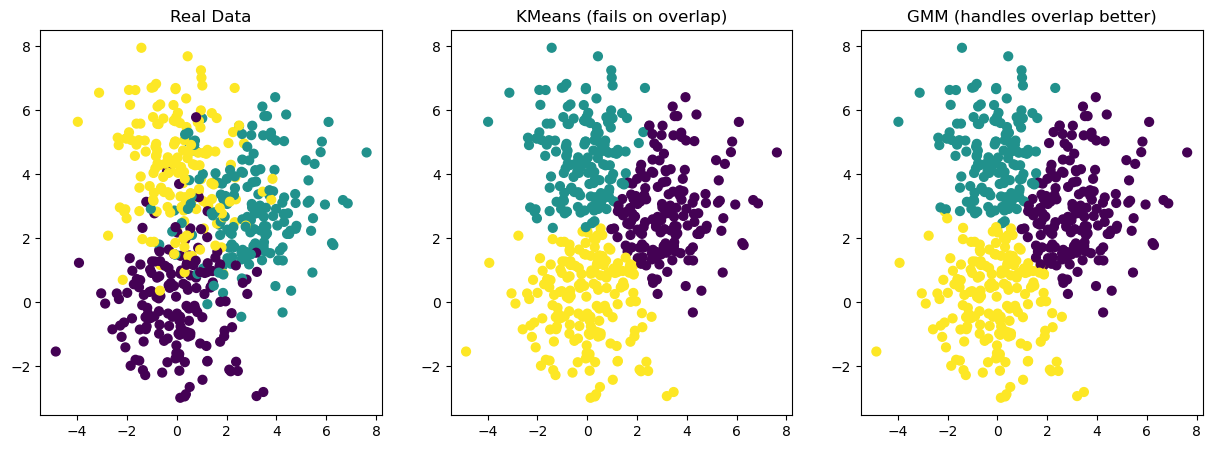

In [13]:
X,y_true=make_blobs(
    n_samples=500,
    centers=[(0,0),(3,3),(0,4)],
    cluster_std=[1.5,1.5,1.5],
    random_state=42
)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.scatter(X[:,0],X[:,1],c=y_true,s=40)
plt.title("Real Data")

#------------------------------------------------------------------------------------------------------------------------------------------------------

kmeans=KMeans(n_clusters=3, random_state=42)
k_pred=kmeans.fit_predict(X)

plt.subplot(1,3,2)
plt.scatter(X[:,0],X[:,1],c=k_pred,s=40)
plt.title("KMeans (fails on overlap)")

#------------------------------------------------------------------------------------------------------------------------------------------------------

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

gmm=GaussianMixture(n_components=3,random_state=42)
gmm_pred=gmm.fit_predict(X_scaled)

plt.subplot(1,3,3)
plt.scatter(X[:,0],X[:,1],c=gmm_pred,s=40)
plt.title("GMM (handles overlap better)")

plt.show()

# ML Program 7
---

## Dependencies for ML-7

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def local_regression(query_point,X,Y,tau):
    query_point=np.array([1, query_point])
    X_bias=np.array([[1,x] for x in X])
    distances=np.sum((X_bias - query_point) ** 2,axis=1)
    weights=np.exp(-distances/(2*tau**2))
    weighted_X_transpose=(X_bias.T * weights)
    theta=np.linalg.pinv(weighted_X_transpose @ X_bias) @ (weighted_X_transpose @ Y)
    return theta @ query_point

def draw(tau):
    predictions = [local_regression(x0,X,Y,tau) for x0 in domain]

    plt.figure(figsize=(6,4))
    plt.scatter(X, Y, color='black', label='Data Points')
    plt.plot(domain, predictions, color='red', label=f'LWR Fit ({tau=})')
    plt.xlabel("X Values")
    plt.ylabel("Y Values")
    plt.title(f"Locally Weighted Regression ({tau=})")
    plt.legend()
    plt.show()

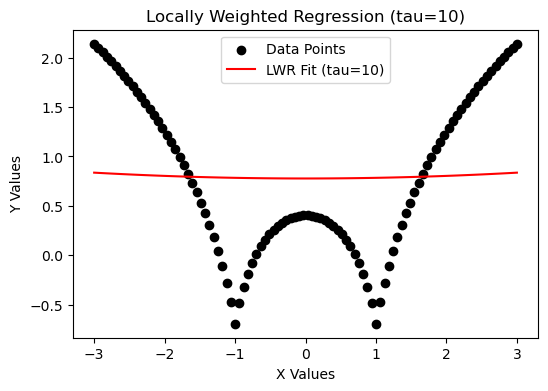

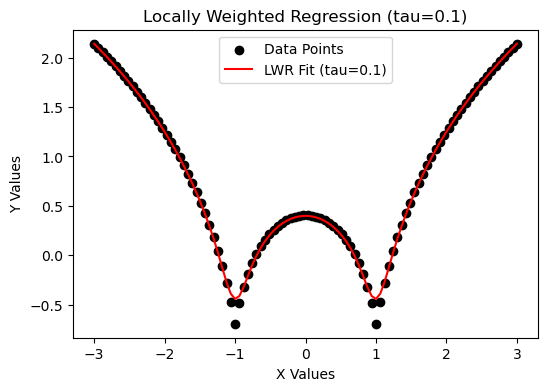

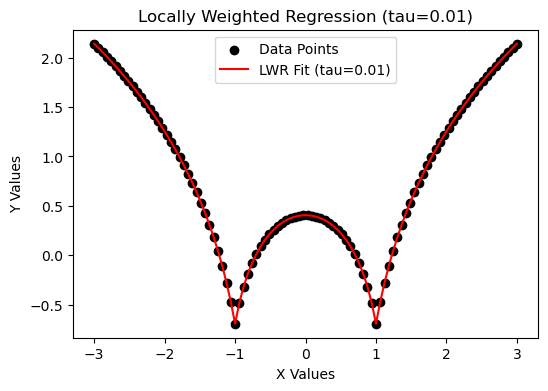

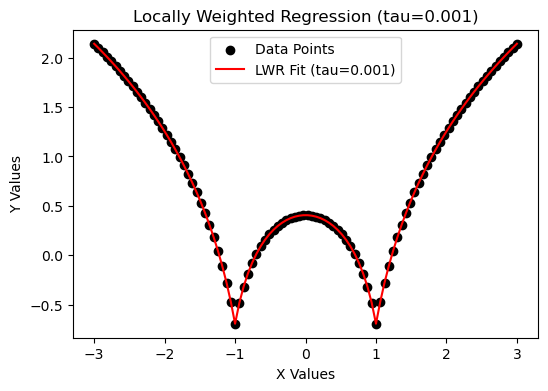

In [10]:
X=np.linspace(-3,3,num=100)
domain=X
Y=np.log(np.abs((X**2)-1)+0.5)
draw(10)
draw(0.1)
draw(0.01)
draw(0.001)